In [13]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import json
from scipy.stats import binom
from scipy.integrate import solve_ivp

In [14]:
OMEGA_BASELINE = 5.0


def load_group_statistics(network, path="Data/group_statistics.txt"):
    with open(path, "r") as f:
        results = json.load(f)
    data = results[network]
    n_vals, p_vals = data["group_size_n"], data["group_size_p"]
    k_vals, g_vals = data["membership_k"], data["membership_g"]
    nmax = int(max(n_vals))
    mmax = int(max(k_vals))
    pn = np.zeros(nmax + 1)
    gm = np.zeros(mmax + 1)
    for n, p in zip(n_vals, p_vals):
        pn[int(n)] = float(p)
    for k, g in zip(k_vals, g_vals):
        gm[int(k)] = float(g)
    state_meta = _get_state_meta(mmax, nmax, gm, pn)
    return gm, pn, mmax, nmax, state_meta


def _get_state_meta(mmax, nmax, gm, pn):
    m = np.arange(0, mmax + 1)
    imat = np.zeros((nmax + 1, nmax + 1))
    nmat = np.zeros((nmax + 1, nmax + 1))
    for n in range(2, nmax + 1):
        imat[n, :n + 1] = np.arange(n + 1)
        nmat[n, :n + 1] = n
    pnmat = np.outer(pn, np.ones(nmax + 1))
    return (mmax, nmax, m, np.array(gm), np.array(pn), imat, nmat, pnmat)


def _infection_matrix(lam, nu, nmax):
    inf_mat = np.zeros((nmax + 1, nmax + 1))
    for n in range(2, nmax + 1):
        for i in range(n):
            inf_mat[n, i] = lam * i ** nu
    return inf_mat


def w_diversity_tension(n, i, alpha):
    phi = i / n
    return alpha * phi * (1 - phi)


def w_tension_shifted(n, i, alpha):
    phi = i / n
    return alpha * phi * (1 - phi) + OMEGA_BASELINE


def w_mixture(n, i, alpha):
    phi = i / n
    return alpha * (phi * (1 - phi) + (1 - 2 * phi) ** 2)


_KERNEL_FUNCS = {
    'diversity_tension': w_diversity_tension,
    'tension_shifted':   w_tension_shifted,
    'mixture':           w_mixture,
}


def _switching_matrix(nmax, alpha, kernel='diversity_tension'):
    if kernel not in _KERNEL_FUNCS:
        raise ValueError(f"Unknown kernel '{kernel}'. Choices: {list(_KERNEL_FUNCS)}")
    f = _KERNEL_FUNCS[kernel]
    w_mat = np.zeros((nmax + 1, nmax + 1))
    for n in range(2, nmax + 1):
        for i in range(n + 1):
            w_mat[n, i] = f(n, i, alpha)
    return w_mat


def _initialize(state_meta, I0):
    mmax, nmax = state_meta[0], state_meta[1]
    sm = np.full(mmax + 1, 1.0 - I0)
    fni = np.zeros((nmax + 1, nmax + 1))
    for n in range(2, nmax + 1):
        fni[n, :n + 1] = binom.pmf(np.arange(n + 1), n, I0)
    return sm, fni


def _infected_fraction(sm, gm):
    return float(np.sum((1.0 - sm) * gm))


def _vector_field(v, t, inf_mat, w_mat, state_meta, mu):
    mmax, nmax = state_meta[0], state_meta[1]
    m, gm, pn = state_meta[2], state_meta[3], state_meta[4]
    imat, nmat, pnmat = state_meta[5], state_meta[6], state_meta[7]

    sm  = v[:mmax + 1]
    fni = v[mmax + 1:].reshape((nmax + 1, nmax + 1))

    denom_r = np.sum((nmat[2:] - imat[2:]) * fni[2:] * pnmat[2:])
    r = (np.sum(inf_mat[2:] * (nmat[2:] - imat[2:]) * fni[2:] * pnmat[2:]) / denom_r
         if denom_r > 1e-14 else 0.0)

    denom_rho = np.sum(m * sm * gm)
    rho = (r * np.sum(m * (m - 1) * sm * gm) / denom_rho
           if denom_rho > 1e-14 else 0.0)

    I = _infected_fraction(sm, gm)

    S_w_denom = np.sum(nmat[2:] * w_mat[2:] * fni[2:] * pnmat[2:])
    S_w = (np.sum((nmat[2:] - imat[2:]) * w_mat[2:] * fni[2:] * pnmat[2:]) / S_w_denom
           if S_w_denom > 1e-14 else 1.0 - I)

    sm_field = mu * (1.0 - sm) - sm * m * r

    fni_field = np.zeros_like(fni)
    fni_field[2:, :nmax] += imat[2:, 1:] * (mu + w_mat[2:, 1:] * S_w) * fni[2:, 1:]
    fni_field[2:] += (
        -imat[2:] * (mu + w_mat[2:] * S_w)
        - (nmat[2:] - imat[2:]) * (inf_mat[2:] + rho + w_mat[2:] * (1.0 - S_w))
    ) * fni[2:]
    fni_field[2:, 1:nmax + 1] += (
        (nmat[2:, :nmax] - imat[2:, :nmax])
        * (inf_mat[2:, :nmax] + rho + w_mat[2:, :nmax] * (1.0 - S_w))
        * fni[2:, :nmax]
    )
    return np.concatenate((sm_field, fni_field.reshape((nmax + 1) ** 2)))


def run_to_stationarity(lam, nu, alpha, gm, state_meta, mmax, nmax, mu, I0,
                         kernel='diversity_tension',
                         traj_points=3000, t_max=300.0):
    inf_mat = _infection_matrix(lam, nu, nmax)
    w_mat   = _switching_matrix(nmax, alpha, kernel=kernel)
    sm, fni = _initialize(state_meta, I0)
    v0 = np.concatenate((sm, fni.reshape((nmax + 1) ** 2)))
    t  = np.linspace(0.0, t_max, traj_points)
    sol = solve_ivp(
        lambda time, state: _vector_field(state, time, inf_mat, w_mat, state_meta, mu),
        t_span=(t[0], t[-1]), y0=v0, method="LSODA", t_eval=t,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    v_final   = sol.y[:, -1]
    sm_final  = v_final[:mmax + 1]
    fni_final = v_final[mmax + 1:].reshape((nmax + 1, nmax + 1))
    I_final   = _infected_fraction(sm_final, gm)
    return fni_final, I_final


print("Model utilities loaded.")


Model utilities loaded.


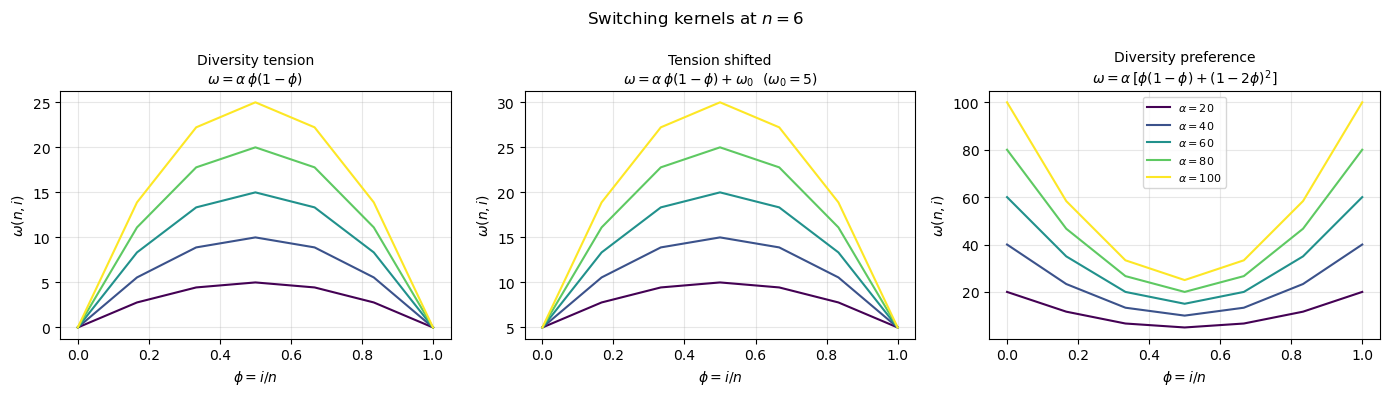

In [15]:
# Visualize all 3 switching kernels at n = nmax across a range of α.
gm, pn, mmax, nmax, state_meta = load_group_statistics("Thiers13")

n = nmax
phi_vals = np.arange(n + 1) / n
alphas = [20, 40, 60, 80, 100]

KERNEL_TITLES = {
    'diversity_tension': "Diversity tension\n"
                         r"$\omega = \alpha\,\phi(1-\phi)$",
    'tension_shifted':   "Tension shifted\n"
                         rf"$\omega = \alpha\,\phi(1-\phi) + \omega_0$  ($\omega_0={OMEGA_BASELINE:g}$)",
    'mixture':           "Diversity preference\n"
                         r"$\omega = \alpha\,[\phi(1-\phi) + (1-2\phi)^2]$",
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cmap = plt.get_cmap("viridis")

for ax, (kernel, title) in zip(axes, KERNEL_TITLES.items()):
    f = _KERNEL_FUNCS[kernel]
    for k, alpha in enumerate(alphas):
        w_vals = [f(n, i, alpha) for i in range(n + 1)]
        ax.plot(phi_vals, w_vals,
                color=cmap(k / max(len(alphas) - 1, 1)),
                label=rf"$\alpha={alpha}$")
    ax.set_xlabel(r"$\phi = i/n$")
    ax.set_ylabel(r"$\omega(n, i)$")
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)

axes[-1].legend(loc="best", fontsize=8)
fig.suptitle(rf"Switching kernels at $n={n}$", fontsize=12)
plt.tight_layout()
plt.savefig("./figures/switching_kernels.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
ALPHA_VALUES   = np.logspace(-1, 2.5, 5).tolist()
print("Alpha values for sweep:", ALPHA_VALUES)

Alpha values for sweep: [0.1, 0.7498942093324559, 5.623413251903491, 42.169650342858226, 316.22776601683796]


In [17]:
# Group files by (date, network, kernel).
# Within a group, picks the most recent file per alpha (timestamp sort).
from collections import defaultdict

KERNEL_CHOICES = ['diversity_tension', 'tension_shifted', 'mixture']

def _parse_stem(path):
    stem = os.path.basename(path).replace('.npz', '')
    date = '2026-05-06'
    rest = stem[11:]  # strip YYYY-MM-DD_
    for kernel in KERNEL_CHOICES:
        sep = f'_{kernel}_alpha_'
        if sep in rest:
            return date, rest.split(sep)[0], kernel
    # legacy format: _kernel_alpha_
    if '_kernel_alpha_' in rest:
        return date, rest.split('_kernel_alpha_')[0], 'diversity_tension'
    raise ValueError(f"Unrecognized filename: {stem}")

_all_sweep = [
    f for f in glob.glob('Files/vacc/*_alpha_*.npz')
    if '_baseline' not in os.path.basename(f)
]
if not _all_sweep:
    raise FileNotFoundError("No kernel sweep files found in Files/vacc/")

all_combos = sorted(set(_parse_stem(f) for f in _all_sweep))
print(f'Found {len(all_combos)} (date, network, kernel) combination(s):')

all_data = {}
for DATE, NETWORK, KERNEL in all_combos:
    by_alpha = defaultdict(list)
    for f in _all_sweep:
        try:
            d, n, k = _parse_stem(f)
        except ValueError:
            continue
        if d == DATE and n == NETWORK and k == KERNEL:
            by_alpha[float(np.load(f)['alpha'])].append(f)

    if not by_alpha:
        continue

    runs = []
    for alpha in sorted(by_alpha):
        f = sorted(by_alpha[alpha])[-1]
        d = np.load(f)
        runs.append({
            'alpha':  float(d['alpha']),
            'delta':  d['delta'],
            'I_low':  d['I_low'],
            'I_high': d['I_high'],
            'lam':    d['lam_grid'],
            'nu':     d['nu_grid'],
        })

    label = f'{DATE}_{NETWORK}_{KERNEL}'
    all_data[label] = {'runs': runs, 'date': DATE, 'network': NETWORK, 'kernel': KERNEL}

    print(f'\n  {label}  ({len(runs)} α values)')
    for r in runs:
        n_bi = int((r['delta'] > 0.05).sum())
        print(f'    alpha={r["alpha"]:5.1f}  max_delta={r["delta"].max():.4f}  bistable_cells={n_bi}')


Found 9 (date, network, kernel) combination(s):

  2026-05-06_Synthetic_poisson_k2_diversity_tension  (4 α values)
    alpha=  0.1  max_delta=0.1620  bistable_cells=49
    alpha=  0.7  max_delta=0.0202  bistable_cells=0
    alpha=  5.6  max_delta=0.0018  bistable_cells=0
    alpha= 42.2  max_delta=0.0006  bistable_cells=0

  2026-05-06_Synthetic_poisson_k2_mixture  (5 α values)
    alpha=  0.1  max_delta=0.2602  bistable_cells=89
    alpha=  0.7  max_delta=0.3840  bistable_cells=122
    alpha=  5.6  max_delta=0.5834  bistable_cells=153
    alpha= 42.2  max_delta=0.8182  bistable_cells=374
    alpha=316.2  max_delta=0.9503  bistable_cells=563

  2026-05-06_Synthetic_poisson_k2_tension_shifted  (5 α values)
    alpha=  0.1  max_delta=0.6200  bistable_cells=207
    alpha=  0.7  max_delta=0.6222  bistable_cells=208
    alpha=  5.6  max_delta=0.6369  bistable_cells=221
    alpha= 42.2  max_delta=0.6790  bistable_cells=276
    alpha=316.2  max_delta=0.6351  bistable_cells=259

  2026-05-06_S

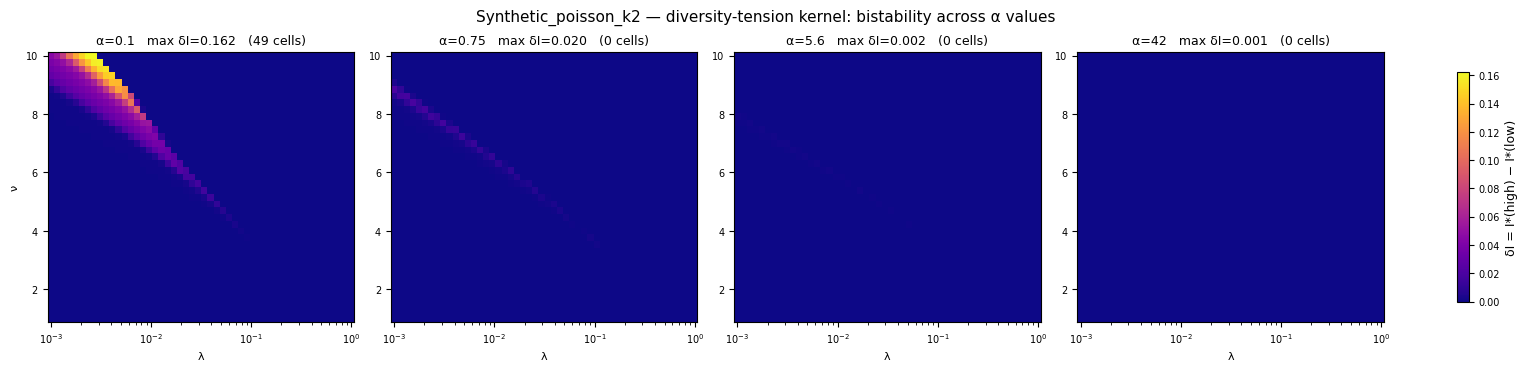

Saved → figures/2026-05-06_Synthetic_poisson_k2_diversity_tension_vacc_sweep_alpha_grid.png


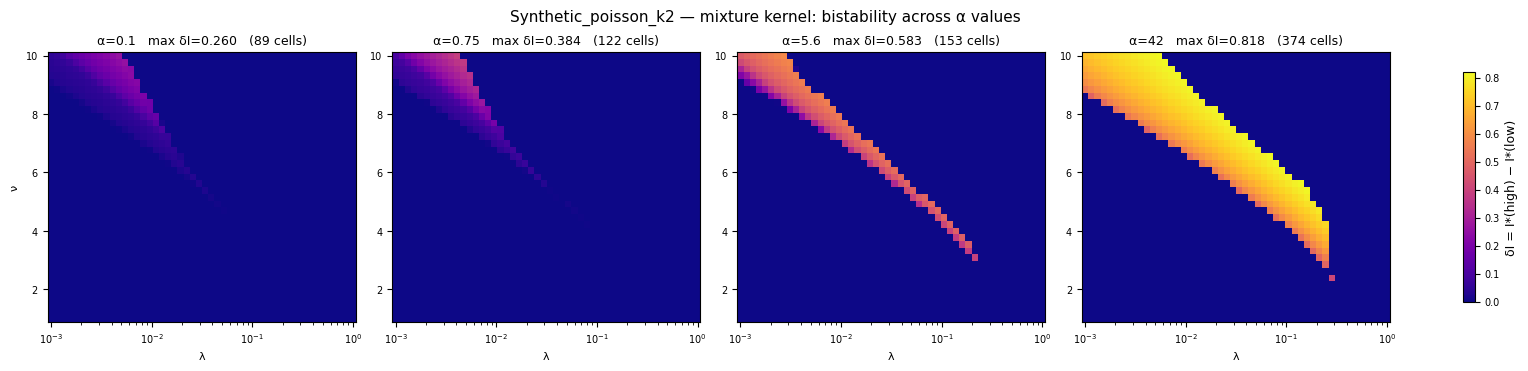

Saved → figures/2026-05-06_Synthetic_poisson_k2_mixture_vacc_sweep_alpha_grid.png


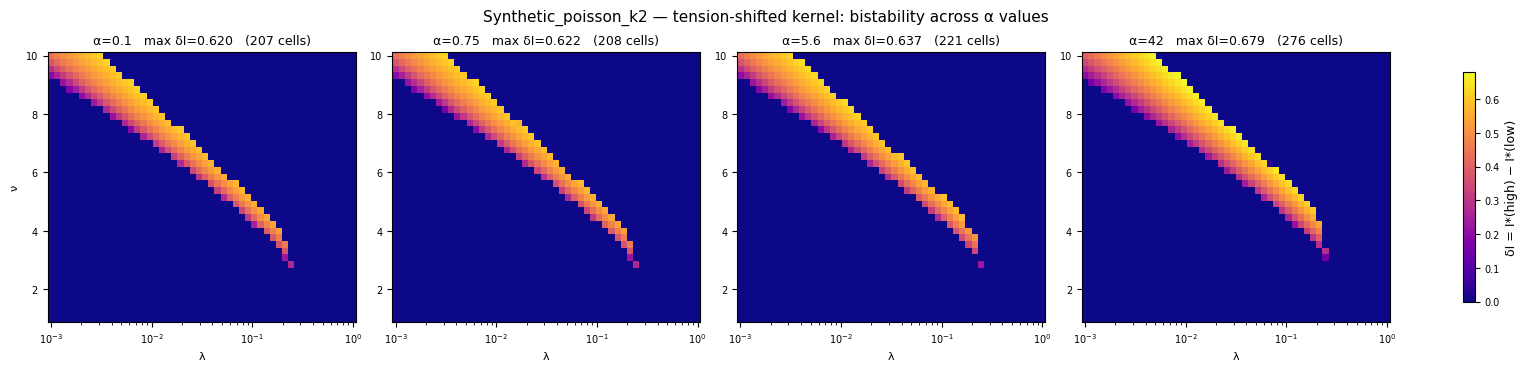

Saved → figures/2026-05-06_Synthetic_poisson_k2_tension_shifted_vacc_sweep_alpha_grid.png


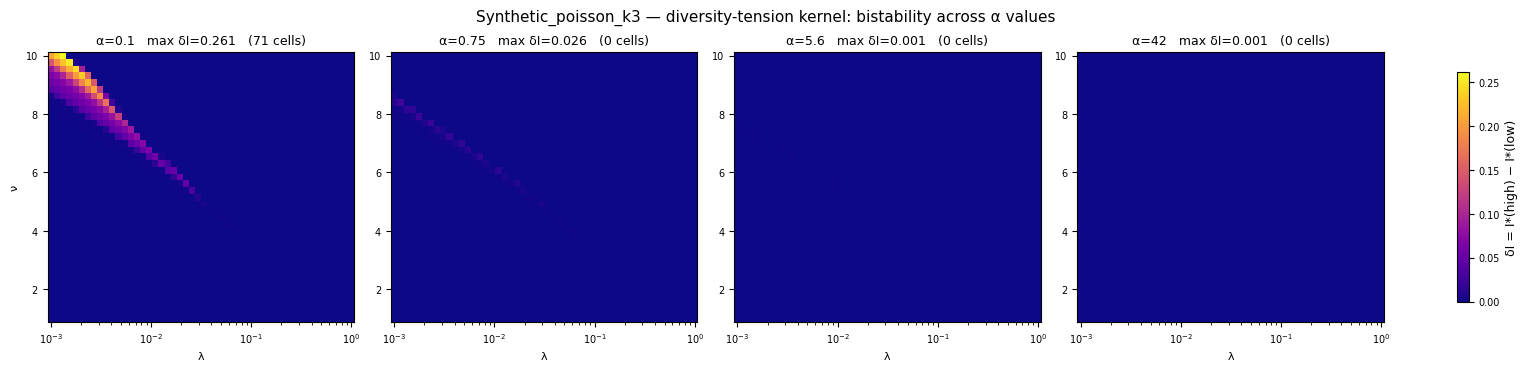

Saved → figures/2026-05-06_Synthetic_poisson_k3_diversity_tension_vacc_sweep_alpha_grid.png


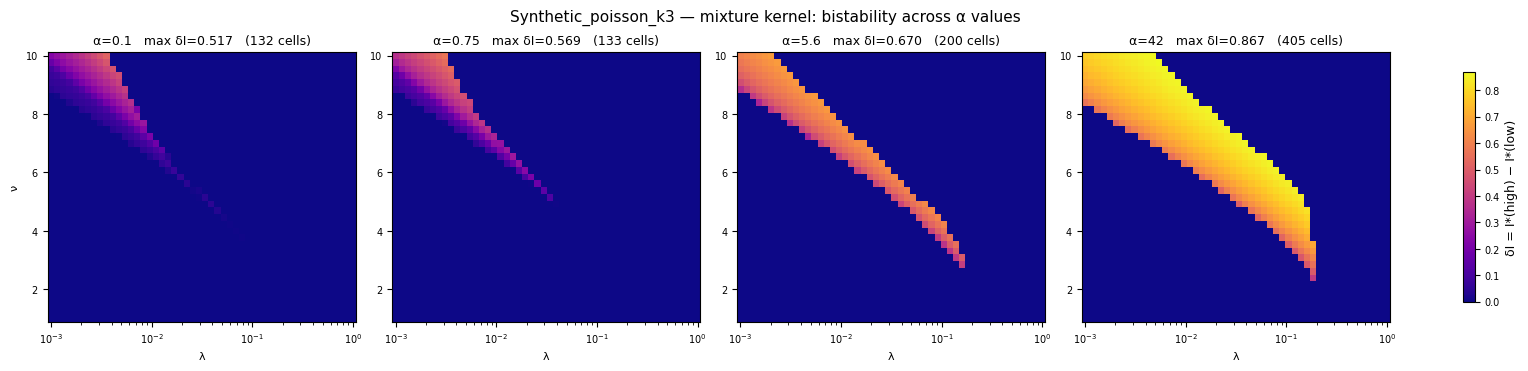

Saved → figures/2026-05-06_Synthetic_poisson_k3_mixture_vacc_sweep_alpha_grid.png


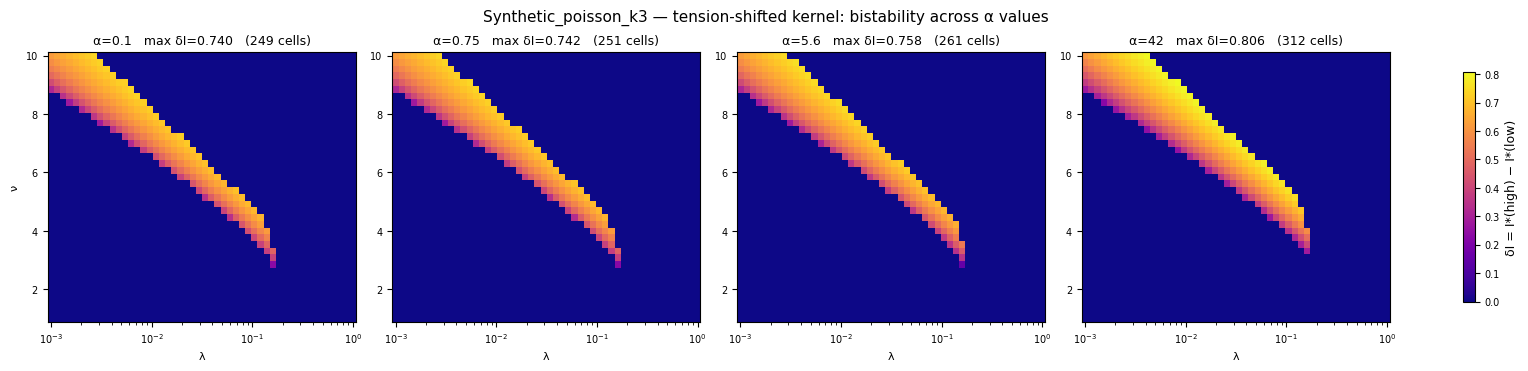

Saved → figures/2026-05-06_Synthetic_poisson_k3_tension_shifted_vacc_sweep_alpha_grid.png


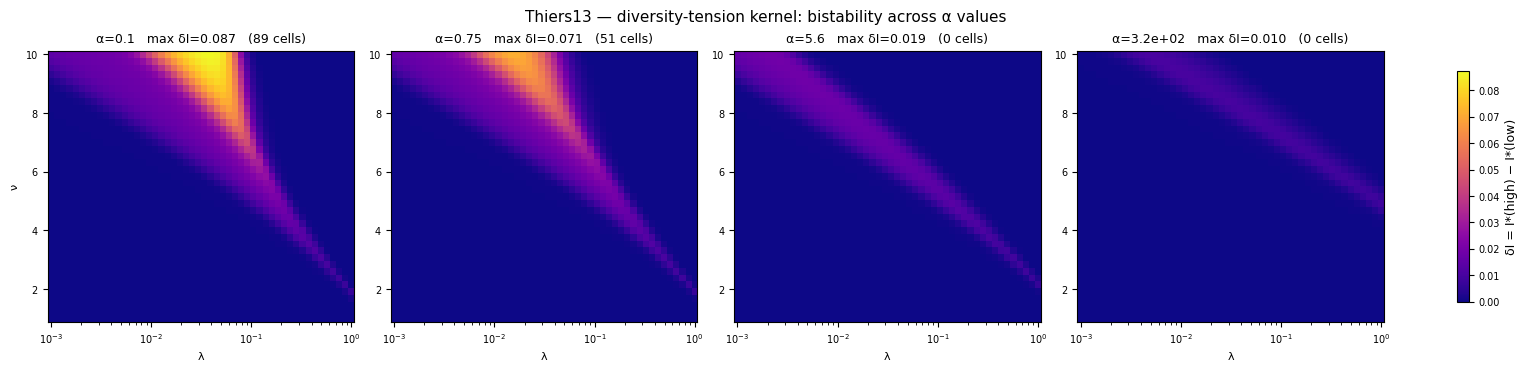

Saved → figures/2026-05-06_Thiers13_diversity_tension_vacc_sweep_alpha_grid.png


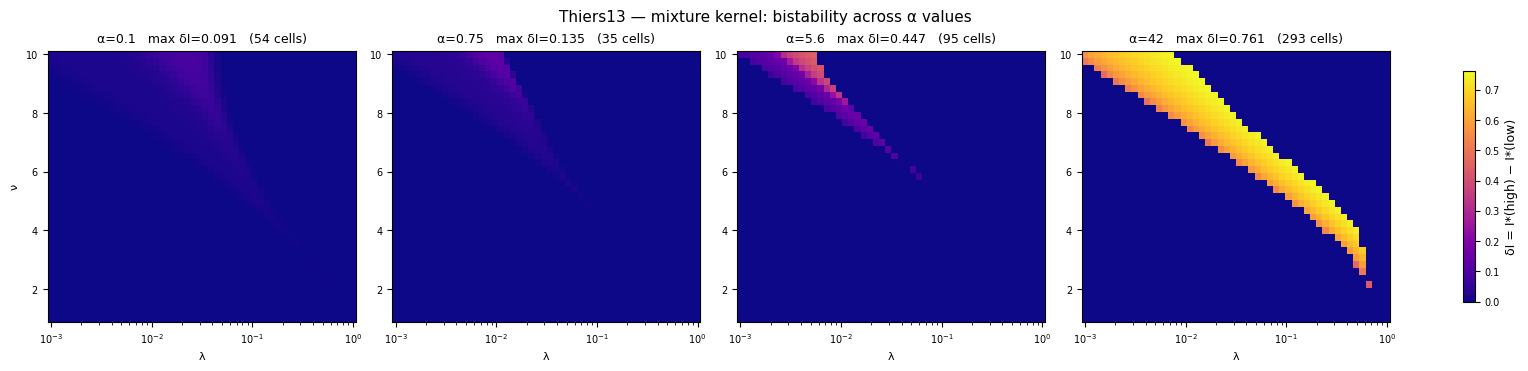

Saved → figures/2026-05-06_Thiers13_mixture_vacc_sweep_alpha_grid.png


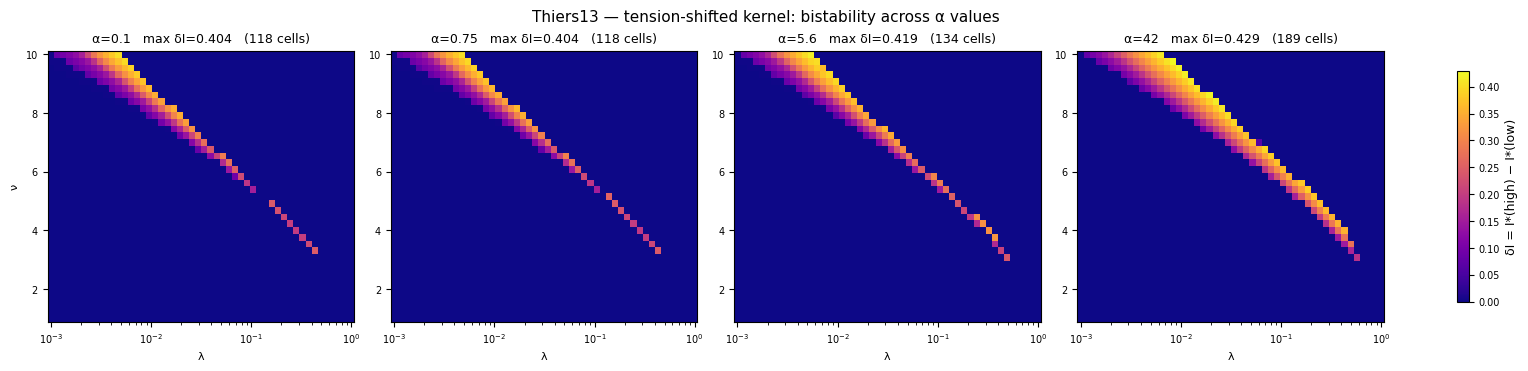

Saved → figures/2026-05-06_Thiers13_tension_shifted_vacc_sweep_alpha_grid.png


In [18]:
# --- Alpha-grid heatmap (one figure per date+network+kernel; baseline plotted separately below) ---

for label, data in all_data.items():
    runs    = data['runs']
    NETWORK = data['network']
    KERNEL  = data['kernel']
    kernel_label = KERNEL.replace('_', '-')

    kernel_panels = runs[:4]
    n_panels = len(kernel_panels)
    if n_panels == 0:
        continue

    vmax = max(r['delta'].max() for r in kernel_panels)

    fig, axes_grid = plt.subplots(
        1, n_panels,
        figsize=(3.8 * n_panels, 3.6),
        constrained_layout=True,
        squeeze=False,
    )
    axes = axes_grid.flatten()

    last_im = None
    for idx, run in enumerate(kernel_panels):
        ax = axes[idx]
        im = ax.pcolormesh(run['lam'], run['nu'], run['delta'].T,
                           vmin=0, vmax=vmax, cmap='plasma', shading='auto')
        ax.set_xscale('log')
        last_im = im
        n_bi = int((run['delta'] > 0.05).sum())
        ax.set_title(
            f'α={run["alpha"]:.2g}   max δI={run["delta"].max():.3f}   ({n_bi} cells)',
            fontsize=9,
        )
        ax.set_xlabel('λ', fontsize=8)
        if idx == 0:
            ax.set_ylabel('ν', fontsize=8)
        ax.tick_params(labelsize=7)

    cbar = fig.colorbar(last_im, ax=axes.tolist(), shrink=0.85)
    cbar.set_label('δI = I*(high) − I*(low)', fontsize=9)
    cbar.ax.tick_params(labelsize=7)

    fig.suptitle(
        f'{NETWORK} — {kernel_label} kernel: bistability across α values',
        fontsize=11,
    )
    outpath = f'figures/{label}_vacc_sweep_alpha_grid.png'
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {outpath}')


In [19]:
# --- Load baseline files (constant ω=5), grouped by (date, network) ---
def _parse_baseline_stem(path):
    stem = os.path.basename(path).replace('.npz', '')
    date = '2026-05-06'
    network = stem[11:].removesuffix('_baseline')
    return date, network

_all_baseline = glob.glob('Files/vacc/*_baseline.npz')

baseline_data = {}
if _all_baseline:
    baseline_combos = sorted(set(_parse_baseline_stem(f) for f in _all_baseline))
    print(f'Found {len(baseline_combos)} baseline file(s):')
    for DATE, NETWORK in baseline_combos:
        files = sorted(glob.glob(f'Files/vacc/{DATE}_{NETWORK}_baseline.npz'))
        if not files:
            continue
        d = np.load(files[-1])
        label = f'{DATE}_{NETWORK}'
        baseline_data[label] = {
            'date':           DATE,
            'network':        NETWORK,
            'I_low':          d['I_low'],
            'I_high':         d['I_high'],
            'delta':          d['delta'],
            'lam':            d['lam_grid'],
            'nu':             d['nu_grid'],
            'omega_baseline': float(d['omega_baseline']),
        }
        n_bi = int((d['delta'] > 0.05).sum())
        print(
            f'  {label}  omega={float(d["omega_baseline"]):.0f}'
            f'  max_delta={d["delta"].max():.4f}  bistable_cells={n_bi}'
        )
else:
    print('No baseline files found in Files/vacc/')

Found 3 baseline file(s):
  2026-05-06_Synthetic_poisson_k2  omega=5  max_delta=0.6199  bistable_cells=206
  2026-05-06_Synthetic_poisson_k3  omega=5  max_delta=0.7394  bistable_cells=248
  2026-05-06_Thiers13  omega=5  max_delta=0.4041  bistable_cells=118


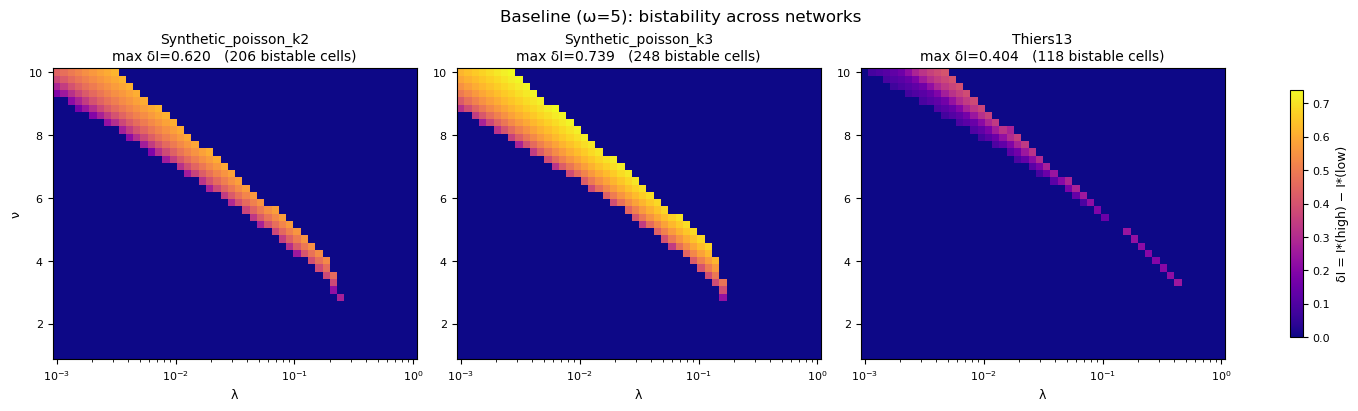

Saved → figures/2026-05-06_baseline_all_networks.png


In [20]:
# --- Combined baseline figure: all networks in one row ---

if baseline_data:
    items = sorted(baseline_data.items(), key=lambda kv: kv[1]['network'])
    n_panels = len(items)
    vmax = max(b['delta'].max() for _, b in items)

    fig, axes_grid = plt.subplots(
        1, n_panels,
        figsize=(4.5 * n_panels, 4.0),
        constrained_layout=True,
        squeeze=False,
    )
    axes = axes_grid.flatten()

    last_im = None
    for ax, (label, b) in zip(axes, items):
        n_bi = int((b['delta'] > 0.05).sum())
        im = ax.pcolormesh(b['lam'], b['nu'], b['delta'].T,
                           vmin=0, vmax=vmax,
                           cmap='plasma', shading='auto')
        ax.set_xscale('log')
        last_im = im
        ax.set_title(
            f"{b['network']}\nmax δI={b['delta'].max():.3f}   ({n_bi} bistable cells)",
            fontsize=10,
        )
        ax.set_xlabel('λ', fontsize=9)
        ax.tick_params(labelsize=8)

    axes[0].set_ylabel('ν', fontsize=9)

    cbar = fig.colorbar(last_im, ax=axes.tolist(), shrink=0.85)
    cbar.set_label('δI = I*(high) − I*(low)', fontsize=9)
    cbar.ax.tick_params(labelsize=8)

    fig.suptitle(f"Baseline (ω={items[0][1]['omega_baseline']:.0f}): bistability across networks", fontsize=12)

    DATE = items[0][1]['date']
    outpath = f'figures/{DATE}_baseline_all_networks.png'
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {outpath}')
else:
    print('No baseline data loaded.')


In [21]:
# --- Peak-bistability summary table (per network × kernel × α) ---
import pandas as pd

table_dictionary = {
    'diversity_tension': "Diversity tension",
    'tension_shifted':   "Tension shifted",
    'mixture':          "Diversity preferred",
}

rows = []
for label, data in all_data.items():
    for run in data['runs']:
        peak_idx = np.unravel_index(run['delta'].argmax(), run['delta'].shape)
        n_bi = int((run['delta'] > 0.05).sum())
        rows.append({
            'network':    data['network'],
            'kernel':     table_dictionary.get(data['kernel'], data['kernel']),
            'alpha':      run['alpha'],
            'lam_star':   float(run['lam'][peak_idx[0]]),
            'nu_star':    float(run['nu'][peak_idx[1]]),
            'I_low':      float(run['I_low'][peak_idx]),
            'I_high':     float(run['I_high'][peak_idx]),
            'delta':      float(run['delta'][peak_idx]),
            'n_bistable': n_bi,
        })

summary_df = (
    pd.DataFrame(rows)
      .sort_values(['kernel', 'network', 'alpha'])
      .reset_index(drop=True)
)

fmt = {
    'alpha':    lambda x: f'{x:.2g}',
    'lam_star': lambda x: f'{x:.2e}',
    'nu_star':  lambda x: f'{x:.2f}',
    'I_low':    lambda x: f'{x:.3f}',
    'I_high':   lambda x: f'{x:.3f}',
    'delta':    lambda x: f'{x:.3f}',
}

for ker, grp in summary_df.groupby('kernel'):
    print(f'\n=== {ker} ===')
    print(grp.drop(columns=['kernel']).to_string(index=False, formatters=fmt))

summary_df.to_csv('figures/peak_bistability_summary.csv', index=False)
print('\nSaved → figures/peak_bistability_summary.csv')

summary_df



=== Diversity preferred ===
             network   alpha lam_star nu_star  I_low I_high delta  n_bistable
Synthetic_poisson_k2     0.1 4.71e-03   10.00  0.001  0.261 0.260          89
Synthetic_poisson_k2    0.75 4.09e-03   10.00  0.002  0.386 0.384         122
Synthetic_poisson_k2     5.6 2.68e-03   10.00  0.001  0.585 0.583         153
Synthetic_poisson_k2      42 5.43e-03   10.00  0.000  0.818 0.818         374
Synthetic_poisson_k2 3.2e+02 1.21e-01    7.46 -0.000  0.950 0.950         563
Synthetic_poisson_k3     0.1 3.56e-03   10.00  0.003  0.520 0.517         132
Synthetic_poisson_k3    0.75 3.09e-03   10.00  0.004  0.573 0.569         133
Synthetic_poisson_k3     5.6 2.02e-03   10.00  0.000  0.671 0.670         200
Synthetic_poisson_k3      42 4.71e-03   10.00  0.000  0.868 0.867         405
Synthetic_poisson_k3 3.2e+02 5.18e-02    8.38  0.000  0.965 0.965         582
            Thiers13     0.1 2.22e-02   10.00  0.002  0.093 0.091          54
            Thiers13    0.75 9.54e-

,network,kernel,alpha,lam_star,nu_star,I_low,I_high,delta,n_bistable
0,Synthetic_poisson_k2,Diversity preferred,0.100000,0.004715,10.000000,9.439243e-04,0.261189,0.260245,89
1,Synthetic_poisson_k2,Diversity preferred,0.749894,0.004095,10.000000,1.631257e-03,0.385587,0.383956,122
2,Synthetic_poisson_k2,Diversity preferred,5.623413,0.002683,10.000000,1.327275e-03,0.584706,0.583379,153
3,Synthetic_poisson_k2,Diversity preferred,42.169650,0.005429,10.000000,7.490892e-05,0.818259,0.818184,374
4,Synthetic_poisson_k2,Diversity preferred,316.227766,0.120679,7.461538,-1.885294e-06,0.950249,0.950250,563
5,Synthetic_poisson_k3,Diversity preferred,0.100000,0.003556,10.000000,2.878974e-03,0.520063,0.517184,132
6,Synthetic_poisson_k3,Diversity preferred,0.749894,0.003089,10.000000,3.827383e-03,0.572538,0.568711,133
7,Synthetic_poisson_k3,Diversity preferred,5.623413,0.002024,10.000000,1.535797e-04,0.670581,0.670427,200
8,Synthetic_poisson_k3,Diversity preferred,42.169650,0.004715,10.000000,1.195531e-04,0.867607,0.867487,405
9,Synthetic_poisson_k3,Diversity preferred,316.227766,0.051795,8.384615,1.342870e-06,0.965277,0.965275,582


## Ridgeline analysis — group-state distributions at stationarity

For each network, we pick the (λ, ν) cell with the highest bistability indicator δI, then re-run the ODE at two contrasting α values (most bistable vs. least bistable) and two initial conditions (I₀ low / high).

The 2×2 ridgeline grid shows fₙᵢ at stationarity. In the bistable row the two panels should look *different* (the system lands in different group-state attractors); in the flat row they should converge to the *same* distribution — directly illustrating the mechanistic consequence of bistability.

In [22]:
# For each (date, network, kernel) combo, pick the (lam, nu) cell with the highest δI
# under the most bistable alpha, then pair it with the least bistable alpha as contrast.

ridge_configs = {}

for label, data in all_data.items():
    runs    = data['runs']
    NETWORK = data['network']
    KERNEL  = data['kernel']

    ranked = sorted(runs, key=lambda r: int((r['delta'] > 0.05).sum()), reverse=True)
    bistable_run = ranked[0]
    flat_run     = ranked[-1]

    peak_idx = np.unravel_index(bistable_run['delta'].argmax(), bistable_run['delta'].shape)
    lam_star = float(bistable_run['lam'][peak_idx[0]])
    nu_star  = float(bistable_run['nu'][peak_idx[1]])

    ridge_configs[label] = {
        'network':        NETWORK,
        'kernel':         KERNEL,
        'lam':            lam_star,
        'nu':             nu_star,
        'alpha_bistable': bistable_run['alpha'],
        'alpha_flat':     flat_run['alpha'],
        'delta_peak':     float(bistable_run['delta'][peak_idx]),
    }
    print(
        f"{NETWORK} ({KERNEL}): lam={lam_star:.3e}  nu={nu_star:.2f}  "
        f"α_bistable={bistable_run['alpha']}  α_flat={flat_run['alpha']}  "
        f"δI_peak={float(bistable_run['delta'][peak_idx]):.3f}"
    )


Synthetic_poisson_k2 (diversity_tension): lam=2.330e-03  nu=10.00  α_bistable=0.09999999999999999  α_flat=42.169650342858226  δI_peak=0.162
Synthetic_poisson_k2 (mixture): lam=1.207e-01  nu=7.46  α_bistable=316.2277660168379  α_flat=0.09999999999999999  δI_peak=0.950
Synthetic_poisson_k2 (tension_shifted): lam=8.286e-03  nu=9.31  α_bistable=42.169650342858226  α_flat=0.09999999999999999  δI_peak=0.679
Synthetic_poisson_k3 (diversity_tension): lam=1.326e-03  nu=10.00  α_bistable=0.09999999999999999  α_flat=316.2277660168379  δI_peak=0.261
Synthetic_poisson_k3 (mixture): lam=5.179e-02  nu=8.38  α_bistable=316.2277660168379  α_flat=0.09999999999999999  δI_peak=0.965
Synthetic_poisson_k3 (tension_shifted): lam=8.286e-03  nu=9.08  α_bistable=42.169650342858226  α_flat=0.09999999999999999  δI_peak=0.806
Thiers13 (diversity_tension): lam=3.907e-02  nu=10.00  α_bistable=0.09999999999999999  α_flat=316.2277660168379  δI_peak=0.087
Thiers13 (mixture): lam=2.812e-01  nu=6.77  α_bistable=316.22776

In [23]:
import time as _time

MU_RIDGE    = 1.0
TRAJ_POINTS = 3000
T_MAX       = 300.0
I0_LOW      = 1e-3
I0_HIGH     = 0.99

ridge_results = {}

for label, cfg in ridge_configs.items():
    NETWORK = cfg['network']
    KERNEL  = cfg['kernel']
    gm, pn, mmax, nmax, state_meta = load_group_statistics(NETWORK)

    results = {}
    for alpha_tag, alpha in [('bistable', cfg['alpha_bistable']),
                              ('flat',     cfg['alpha_flat'])]:
        for i0_tag, I0 in [('low', I0_LOW), ('high', I0_HIGH)]:
            print(f"  {NETWORK} ({KERNEL})  α={alpha}  I0={I0}...", end=' ', flush=True)
            t0 = _time.time()
            fni_final, I_final = run_to_stationarity(
                lam=cfg['lam'], nu=cfg['nu'], alpha=alpha,
                gm=gm, state_meta=state_meta, mmax=mmax, nmax=nmax,
                mu=MU_RIDGE, I0=I0,
                kernel=KERNEL,
                traj_points=TRAJ_POINTS, t_max=T_MAX,
            )
            print(f"I*={I_final:.4f}  ({_time.time()-t0:.1f}s)")
            results[(alpha_tag, i0_tag)] = {'fni_final': fni_final, 'I_final': I_final}

    ridge_results[label] = {'cfg': cfg, 'results': results, 'nmax': nmax}

print("All integrations complete.")


  Synthetic_poisson_k2 (diversity_tension)  α=0.09999999999999999  I0=0.001... I*=0.0000  (0.1s)
  Synthetic_poisson_k2 (diversity_tension)  α=0.09999999999999999  I0=0.99... I*=0.1639  (0.2s)
  Synthetic_poisson_k2 (diversity_tension)  α=42.169650342858226  I0=0.001... I*=0.1543  (0.2s)
  Synthetic_poisson_k2 (diversity_tension)  α=42.169650342858226  I0=0.99... I*=0.1543  (0.2s)
  Synthetic_poisson_k2 (mixture)  α=316.2277660168379  I0=0.001... I*=-0.0000  (0.7s)
  Synthetic_poisson_k2 (mixture)  α=316.2277660168379  I0=0.99... I*=0.9502  (0.2s)
  Synthetic_poisson_k2 (mixture)  α=0.09999999999999999  I0=0.001... I*=0.6320  (0.2s)
  Synthetic_poisson_k2 (mixture)  α=0.09999999999999999  I0=0.99... I*=0.6320  (0.2s)
  Synthetic_poisson_k2 (tension_shifted)  α=42.169650342858226  I0=0.001... I*=0.0000  (0.1s)
  Synthetic_poisson_k2 (tension_shifted)  α=42.169650342858226  I0=0.99... I*=0.6793  (0.2s)
  Synthetic_poisson_k2 (tension_shifted)  α=0.09999999999999999  I0=0.001... I*=0.6865

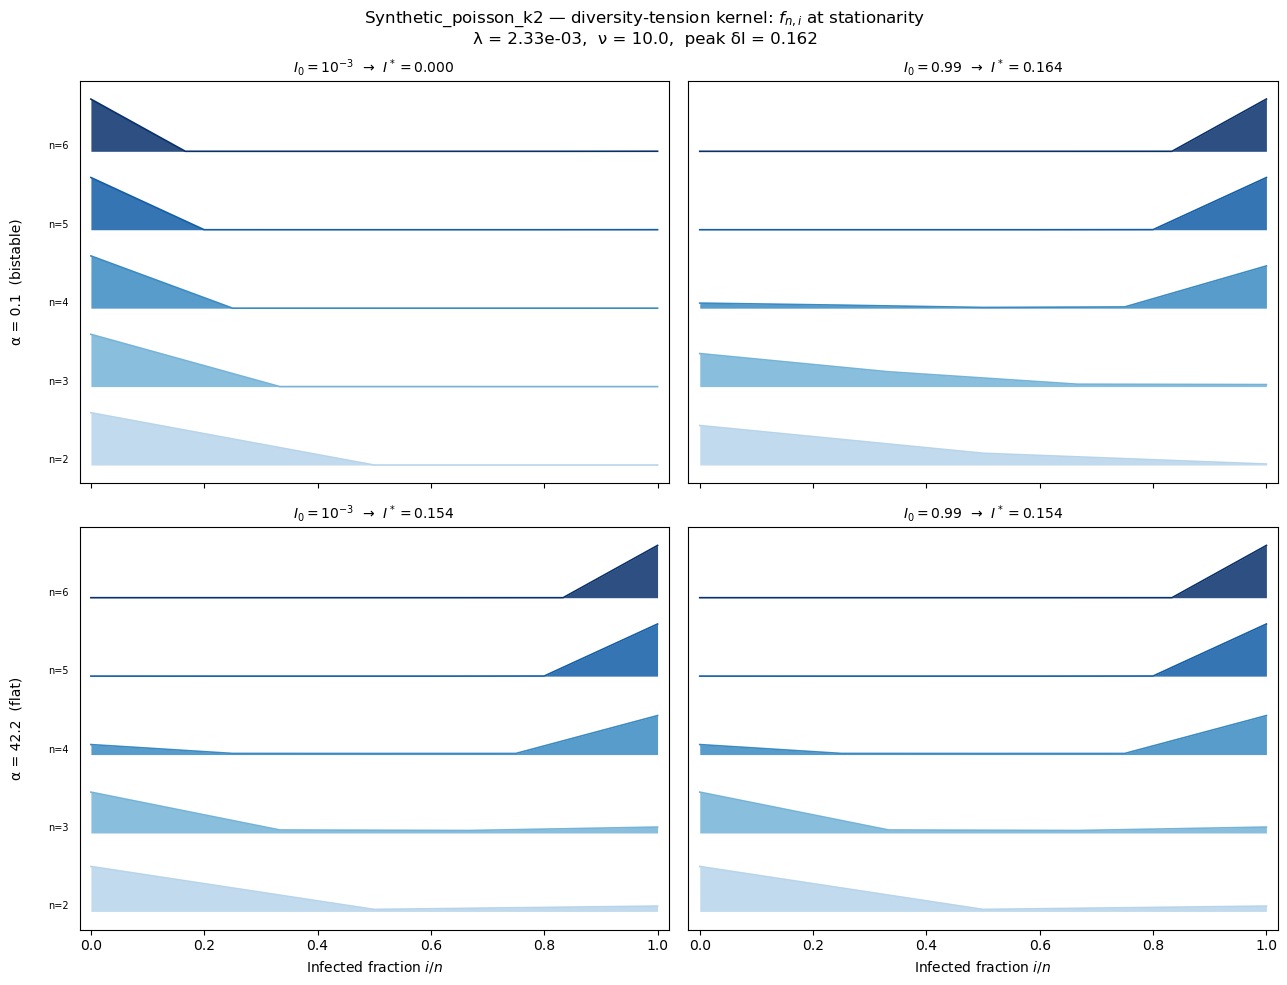

Saved → figures/Synthetic_poisson_k2_diversity_tension_ridgeline_stationary.png


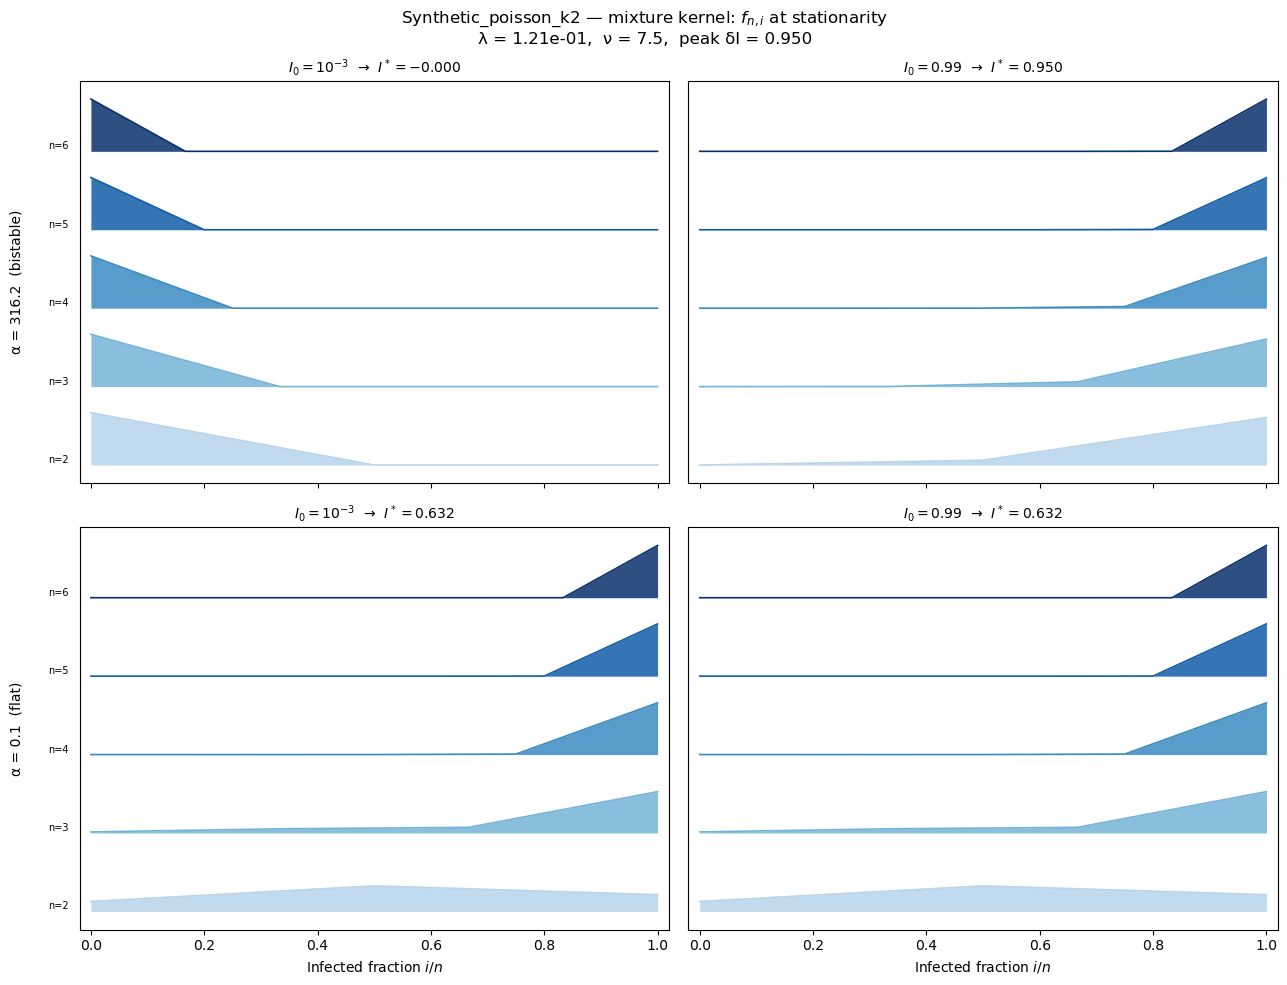

Saved → figures/Synthetic_poisson_k2_mixture_ridgeline_stationary.png


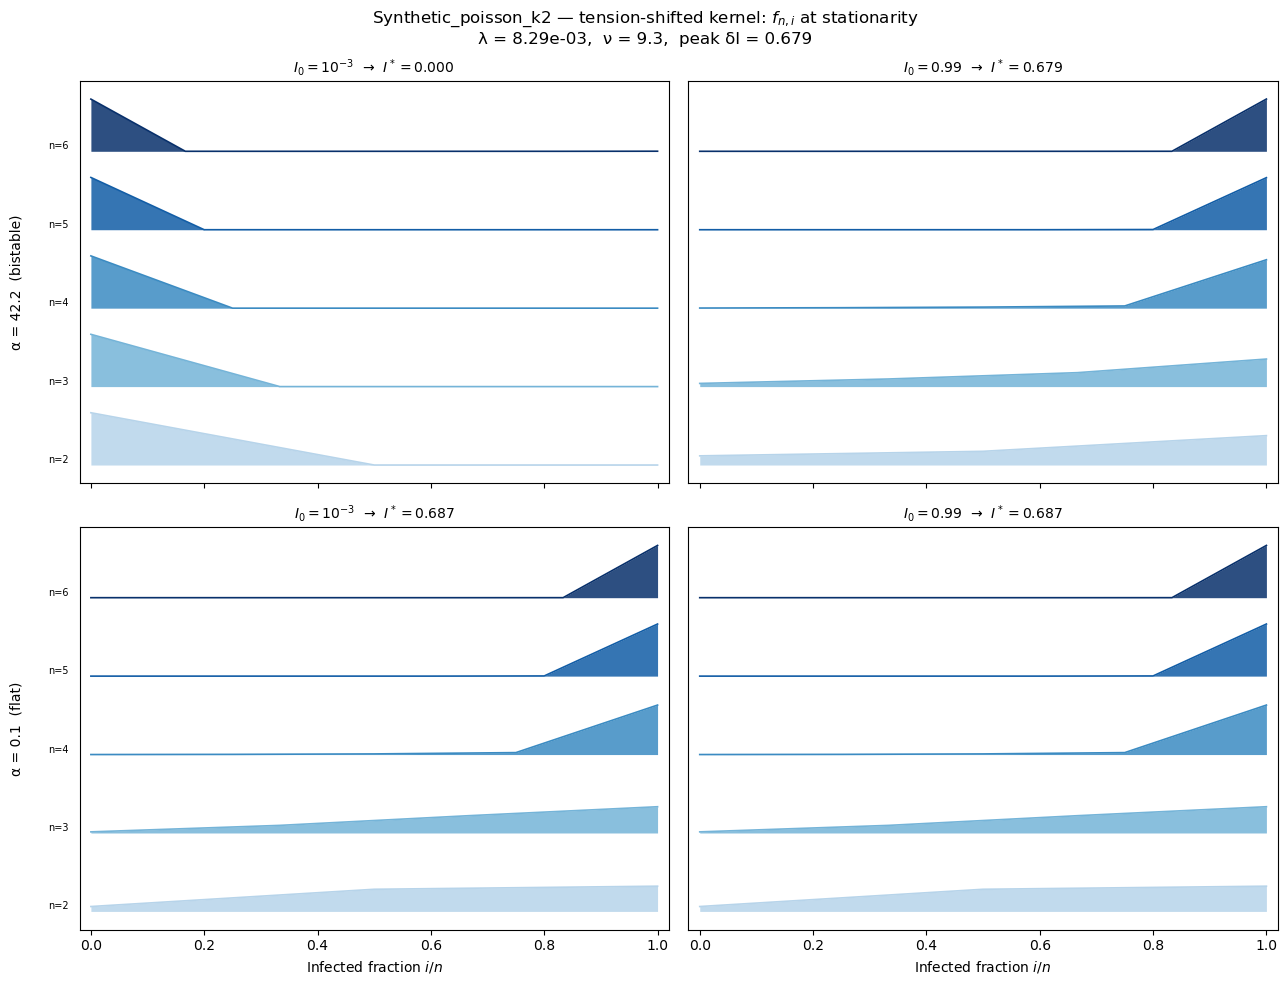

Saved → figures/Synthetic_poisson_k2_tension_shifted_ridgeline_stationary.png


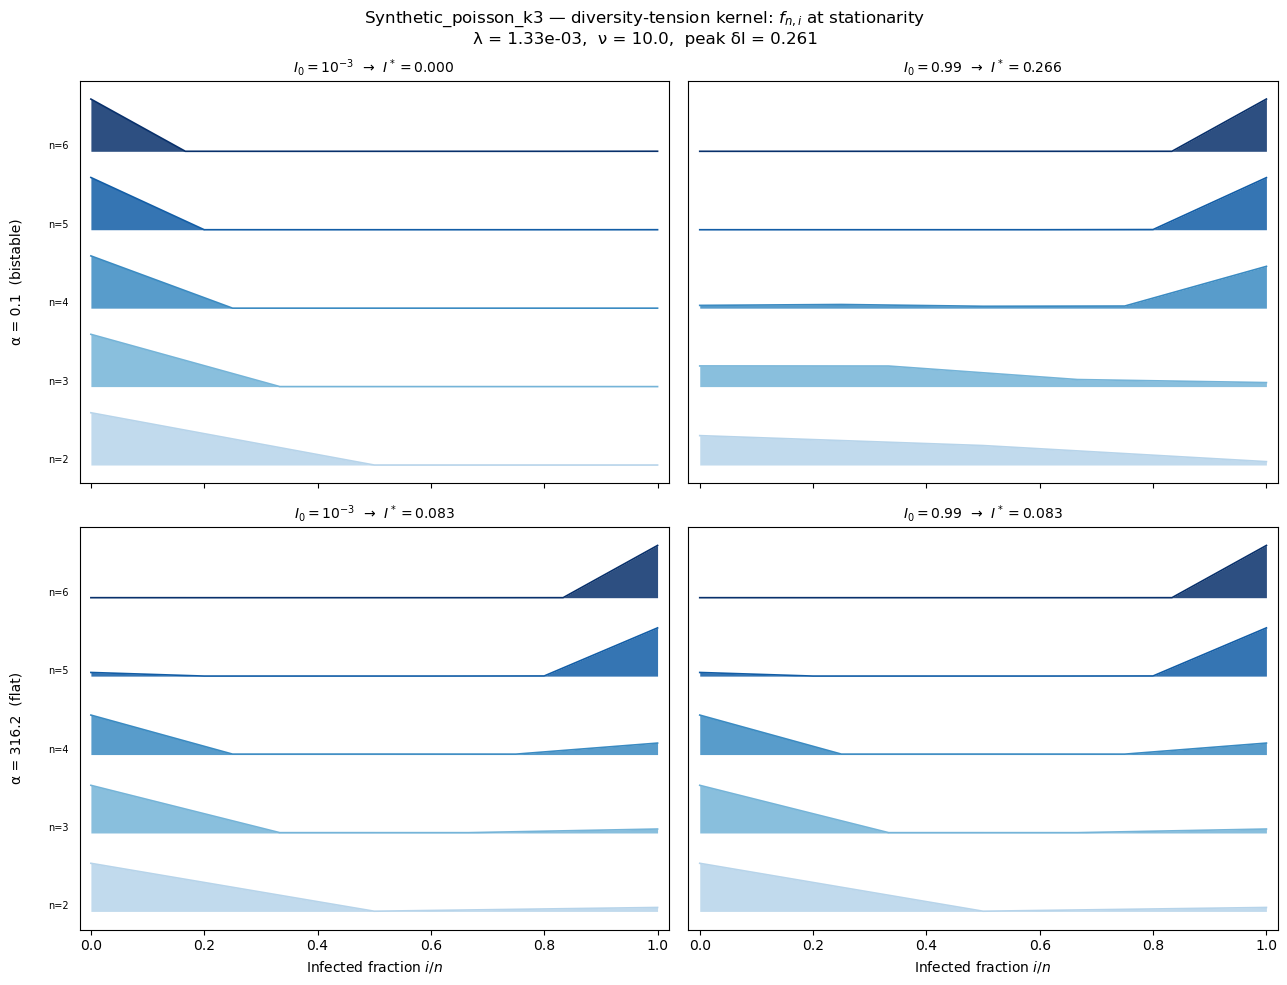

Saved → figures/Synthetic_poisson_k3_diversity_tension_ridgeline_stationary.png


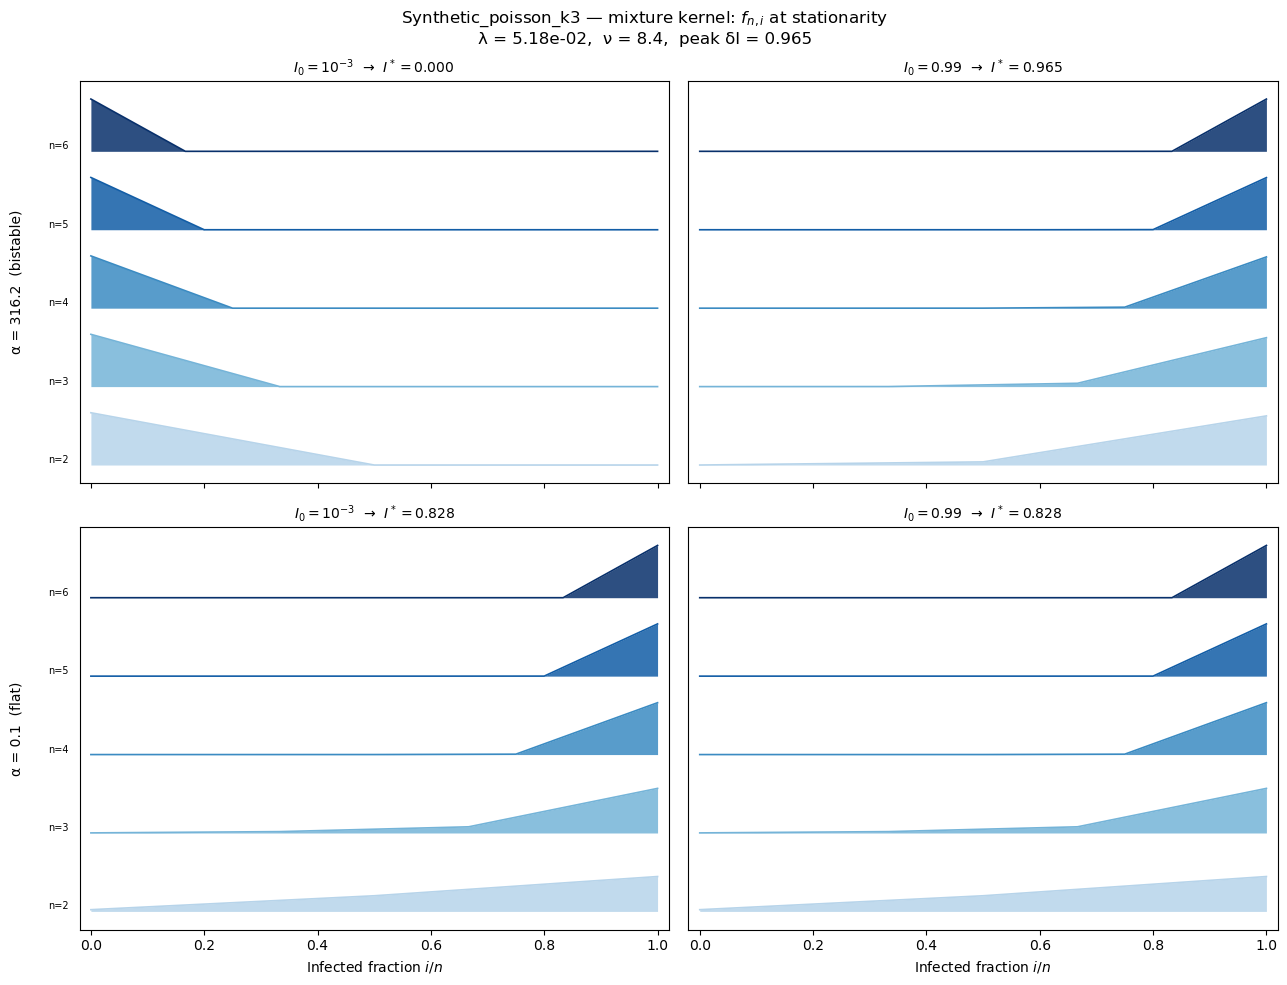

Saved → figures/Synthetic_poisson_k3_mixture_ridgeline_stationary.png


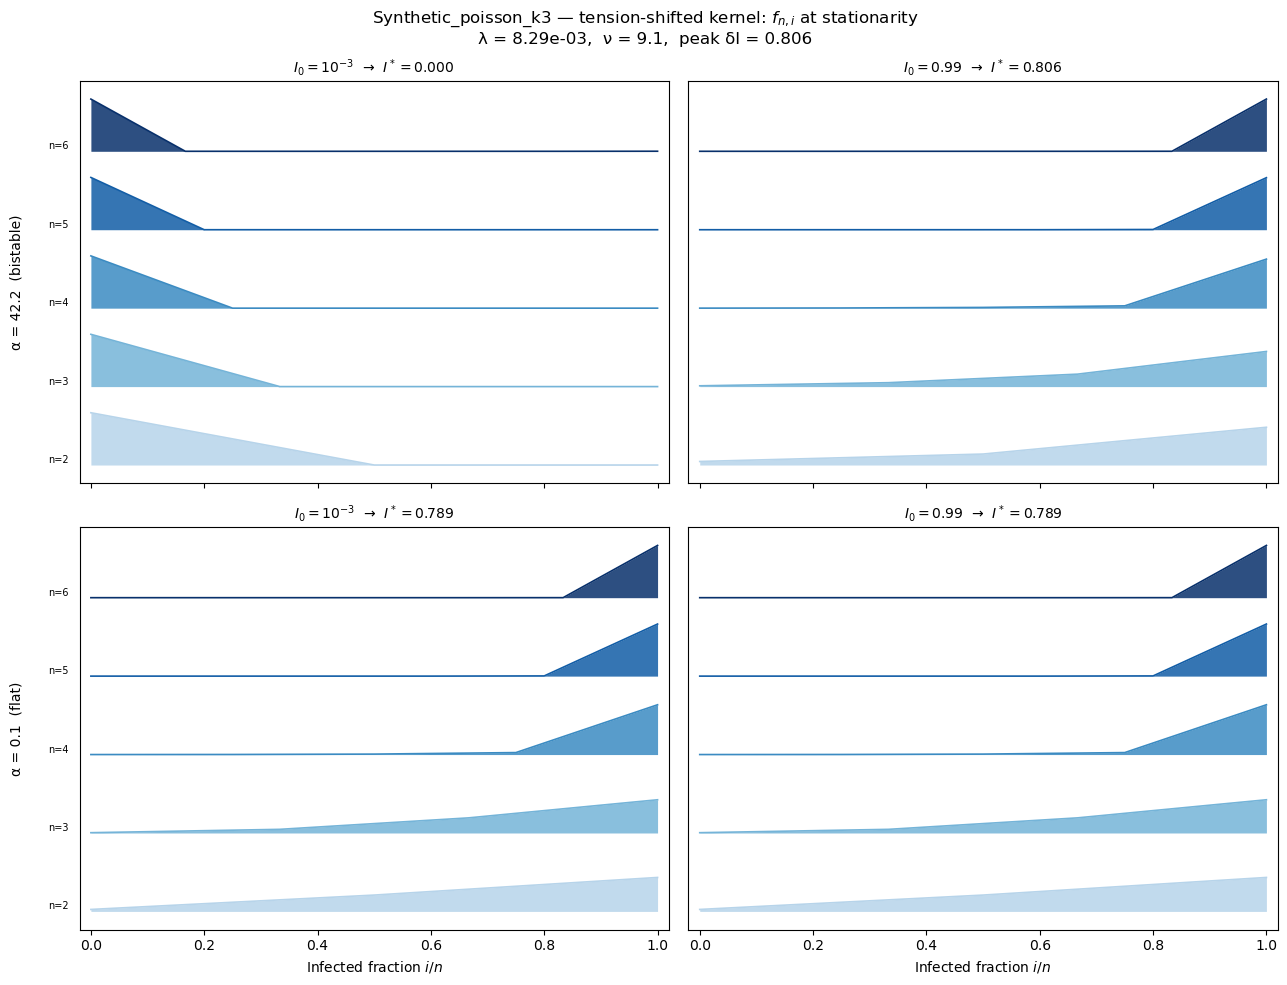

Saved → figures/Synthetic_poisson_k3_tension_shifted_ridgeline_stationary.png


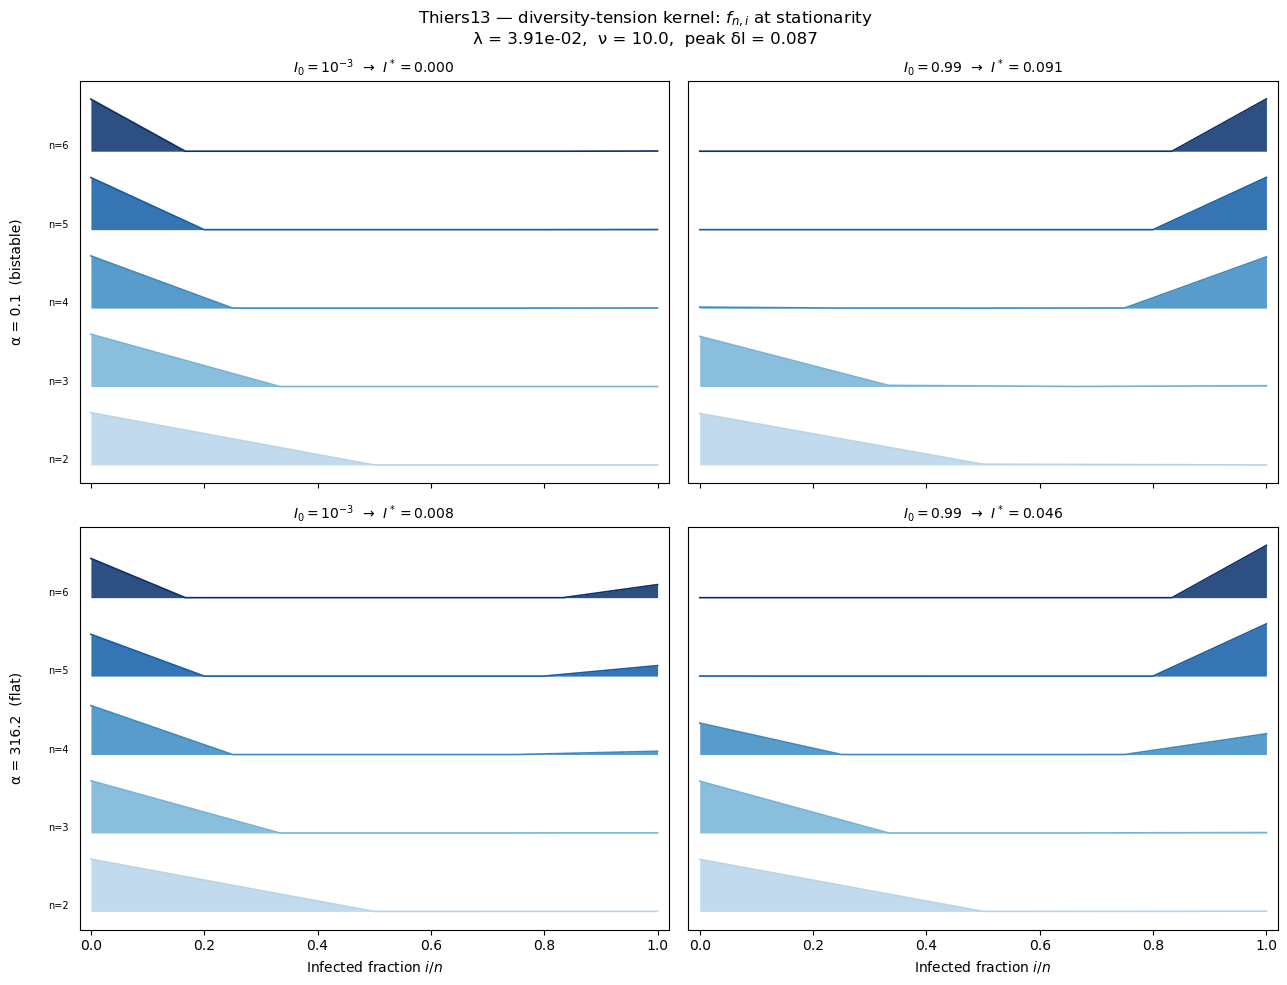

Saved → figures/Thiers13_diversity_tension_ridgeline_stationary.png


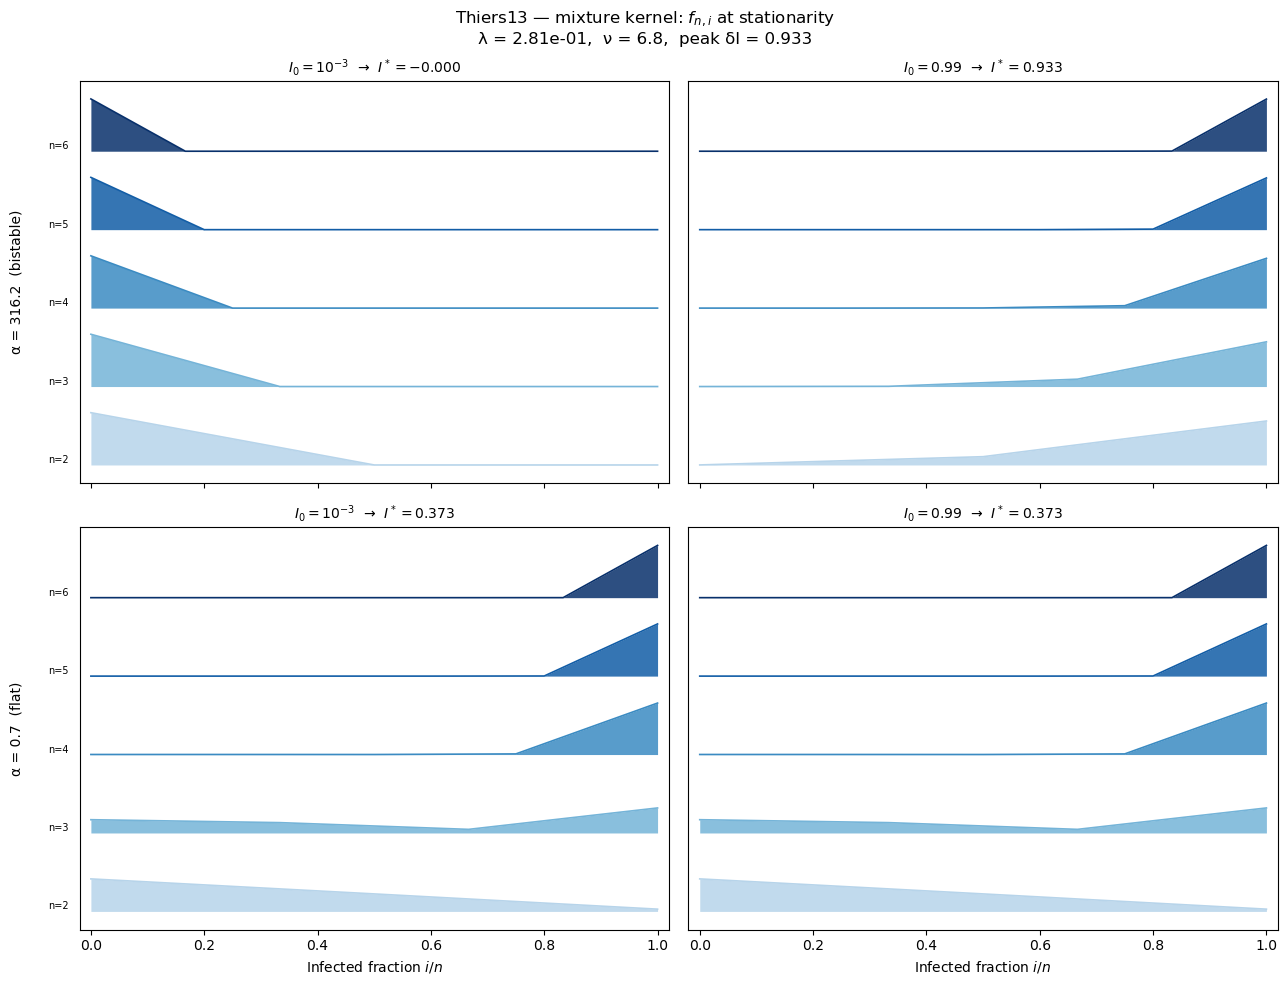

Saved → figures/Thiers13_mixture_ridgeline_stationary.png


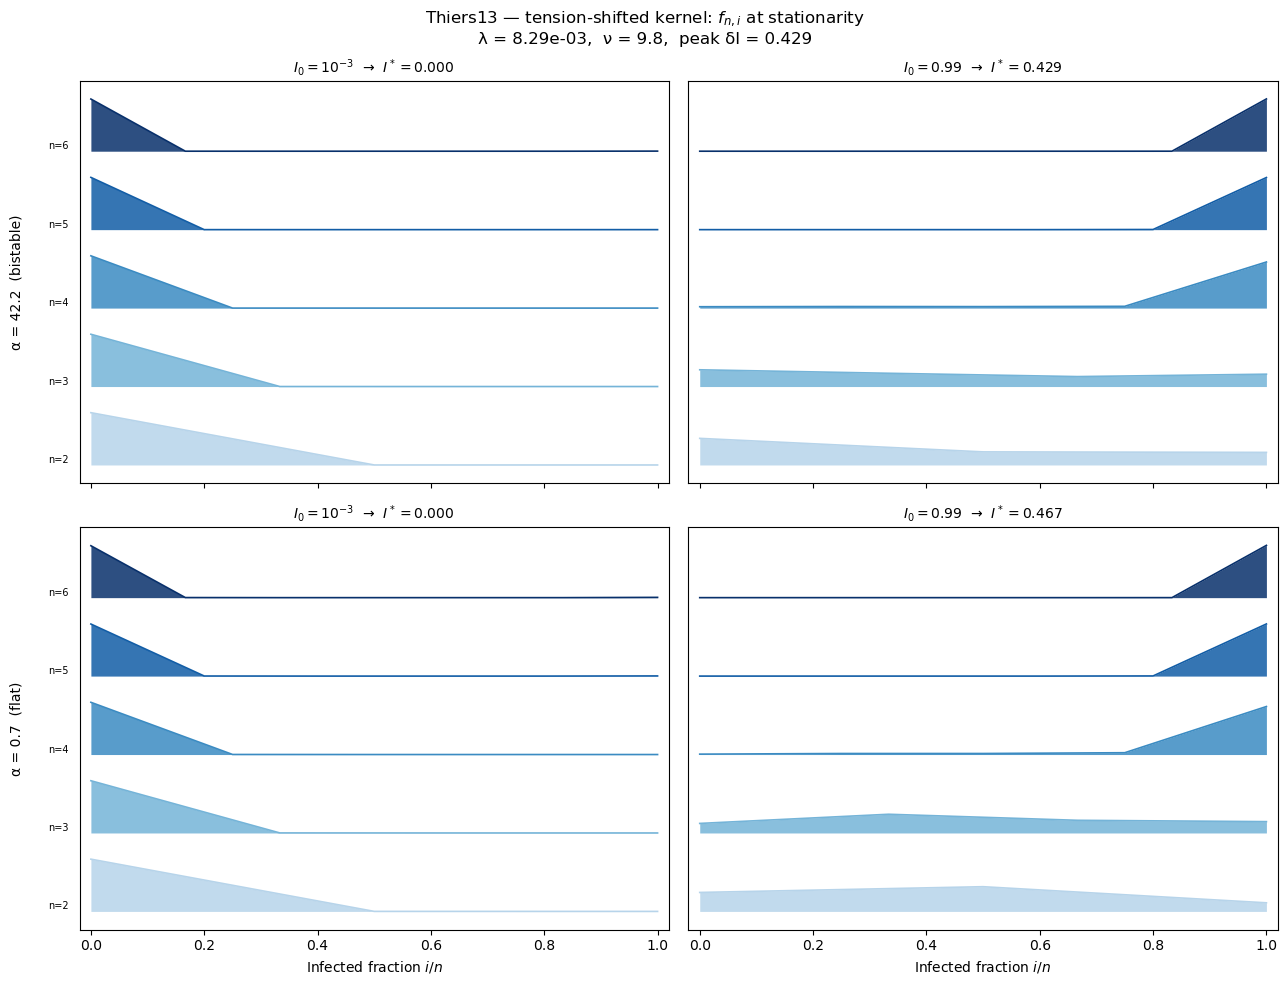

Saved → figures/Thiers13_tension_shifted_ridgeline_stationary.png


In [24]:
from datetime import datetime as _dt

_TIMESTAMP = _dt.now().strftime("%Y-%m-%d")

for label, data in ridge_results.items():
    cfg     = data['cfg']
    results = data['results']
    nmax    = data['nmax']
    NETWORK = cfg['network']
    KERNEL  = cfg['kernel']
    kernel_label = KERNEL.replace('_', '-')

    step   = max(1, nmax // 8)
    n_show = list(range(2, nmax + 1, step))
    if nmax not in n_show:
        n_show.append(nmax)
    n_show = sorted(n_show)

    spacing = 1.5
    cmap    = plt.get_cmap("Blues")
    colors  = [cmap(0.3 + 0.7 * k / max(len(n_show) - 1, 1)) for k in range(len(n_show))]

    fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=True, sharex=True)

    panel_order = [
        ('bistable', 'low',  0, 0),
        ('bistable', 'high', 0, 1),
        ('flat',     'low',  1, 0),
        ('flat',     'high', 1, 1),
    ]

    for a_tag, i0_tag, row, col in panel_order:
        ax      = axes[row, col]
        res     = results[(a_tag, i0_tag)]
        fni     = res['fni_final']
        I_final = res['I_final']
        alpha   = cfg['alpha_bistable'] if a_tag == 'bistable' else cfg['alpha_flat']
        i0_label = f"$I_0 = 10^{{-3}}$" if i0_tag == 'low' else f"$I_0 = 0.99$"

        for k, n0 in enumerate(n_show):
            phi_vals = np.arange(n0 + 1) / n0
            dist     = fni[n0, :n0 + 1].copy()
            total    = dist.sum()
            if total > 1e-14:
                dist /= total
            base = k * spacing
            ax.fill_between(phi_vals, base, base + dist,
                            alpha=0.85, color=colors[k], linewidth=0)
            ax.plot(phi_vals, base + dist, color=colors[k], lw=1.2)
            if col == 0:
                ax.text(-0.04, base, f"n={n0}", ha='right', va='bottom', fontsize=7)

        ax.set_xlim(-0.02, 1.02)
        ax.set_yticks([])
        ax.set_title(f"{i0_label}  →  $I^* = {I_final:.3f}$", fontsize=10)

        if row == 1:
            ax.set_xlabel(r"Infected fraction $i/n$", fontsize=10)

        if col == 0:
            row_label = (
                f"α = {alpha:.1f}  (bistable)"
                if a_tag == 'bistable'
                else f"α = {alpha:.1f}  (flat)"
            )
            ax.set_ylabel(row_label, fontsize=10, labelpad=40)

    fig.suptitle(
        f"{NETWORK} — {kernel_label} kernel: $f_{{n,i}}$ at stationarity\n"
        f"λ = {cfg['lam']:.2e},  ν = {cfg['nu']:.1f},  "
        f"peak δI = {cfg['delta_peak']:.3f}",
        fontsize=12,
    )
    plt.tight_layout()
    outpath = f"figures/{NETWORK}_{KERNEL}_ridgeline_stationary.png"
    plt.savefig(outpath, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved → {outpath}")
